# 📐 Notebook 07: Figure-Level vs Axes-Level Functions

## 🎯 Learning Objectives

In this notebook, you'll master:

- **Axes-level vs Figure-level paradigm** in Seaborn
- When to use `relplot()` vs `scatterplot()`
- **`jointplot()`** for bivariate distributions with marginal plots
- **`lmplot()`** for regression analysis with faceting
- **`relplot()`** for relationship plots with complex layouts
- **`displot()`** for distribution plots with faceting
- When each function type is appropriate

---

## 📚 Key Concepts

### **Axes-Level Functions**
- Work with existing matplotlib axes
- Integrate into complex figure layouts
- Examples: `scatterplot()`, `histplot()`, `boxplot()`, `lineplot()`

### **Figure-Level Functions**
- Create their own figure and subplots
- Built-in faceting capabilities (col, row, hue)
- Return `FacetGrid` or `JointGrid` objects
- Examples: `relplot()`, `displot()`, `catplot()`, `lmplot()`, `jointplot()`

### **When to Use Which?**
- **Axes-level**: Custom layouts, multiple plot types in one figure, fine control
- **Figure-level**: Quick faceting, consistent multi-plot layouts, less code

---

In [1]:
# 📦 Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
from utils.plot_utils import apply_theme, save_fig, stylize_plot

# Apply consistent theme
apply_theme()

In [2]:
# 📊 Load datasets
tips = sns.load_dataset("tips")
penguins = sns.load_dataset("penguins")
diamonds = sns.load_dataset("diamonds")

print("✅ Datasets loaded successfully")
print(f"Tips dataset shape: {tips.shape}")
print(f"Penguins dataset shape: {penguins.shape}")

✅ Datasets loaded successfully
Tips dataset shape: (244, 7)
Penguins dataset shape: (344, 7)


## 1️⃣ Axes-Level vs Figure-Level: Side-by-Side Comparison

Let's start by comparing `scatterplot()` (axes-level) with `relplot()` (figure-level) to understand the key differences.

✅ Plot saved to ../exports/07_figure_level/axes_level_scatter.png


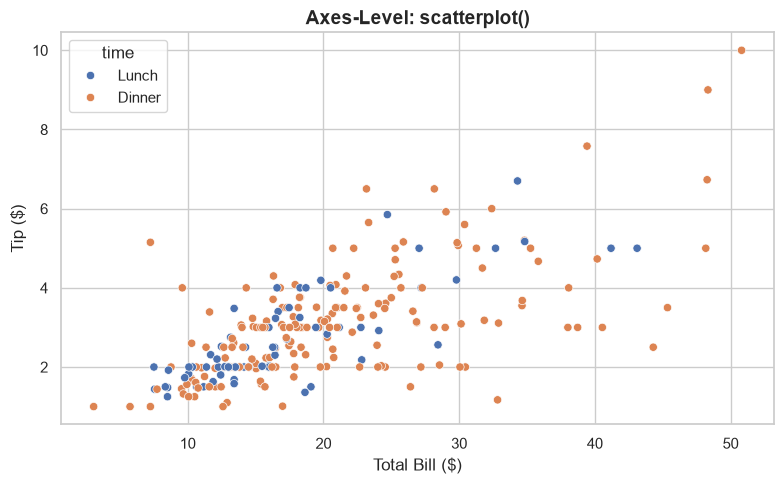

✅ Axes-level plot: Single plot, manual figure control


In [3]:
# 🔹 Axes-Level: scatterplot() - Requires manual figure creation
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time", ax=ax)
stylize_plot(
    title="Axes-Level: scatterplot()", 
    xlabel="Total Bill ($)", 
    ylabel="Tip ($)"
)
save_fig("../exports/07_figure_level/axes_level_scatter.png")
plt.show()

print("✅ Axes-level plot: Single plot, manual figure control")

✅ Plot saved to ../exports/07_figure_level/figure_level_relplot.png


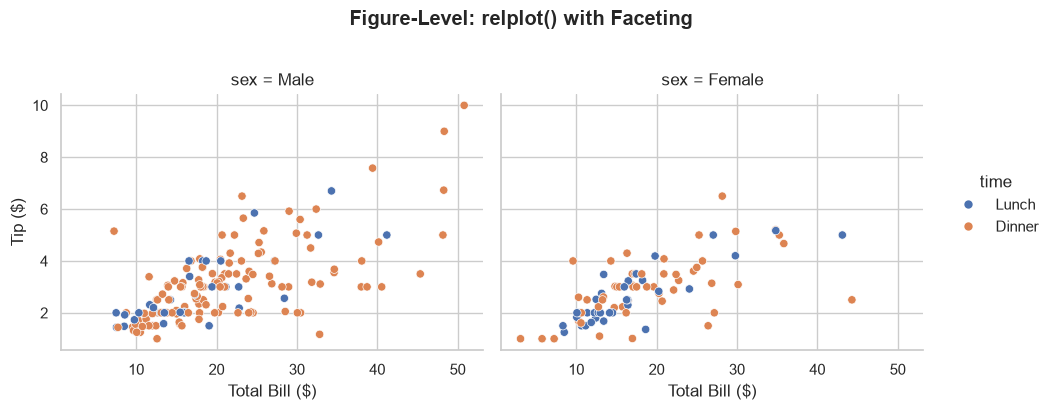

✅ Figure-level plot: Automatic faceting with col parameter


In [4]:
# 🔸 Figure-Level: relplot() - Creates figure automatically with faceting support
g = sns.relplot(
    data=tips, 
    x="total_bill", 
    y="tip", 
    hue="time", 
    col="sex",  # 👈 Built-in faceting!
    height=4, 
    aspect=1.2
)
g.set_axis_labels("Total Bill ($)", "Tip ($)")
g.fig.suptitle("Figure-Level: relplot() with Faceting", y=1.02, fontweight="bold")
g.tight_layout()
save_fig("../exports/07_figure_level/figure_level_relplot.png")
plt.show()

print("✅ Figure-level plot: Automatic faceting with col parameter")

## 2️⃣ `relplot()` - Figure-Level Relationship Plots

**`relplot()`** is the figure-level equivalent of `scatterplot()` and `lineplot()`.

**Key Features:**
- Built-in faceting with `col`, `row`, and `hue`
- Automatically creates `FacetGrid`
- Single function for both scatter and line plots (via `kind` parameter)
- Returns a `FacetGrid` object for further customization

✅ Plot saved to ../exports/07_figure_level/relplot_penguins_faceted.png


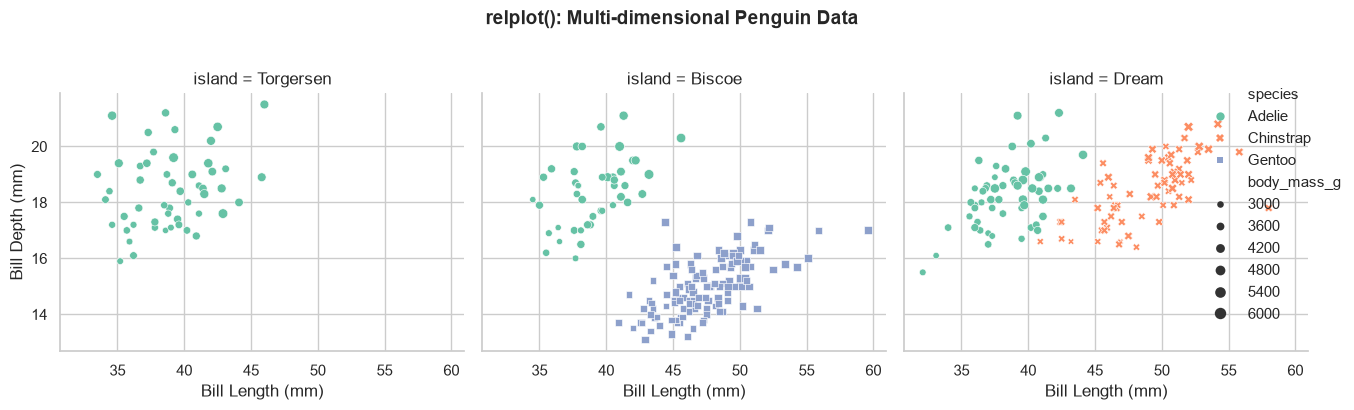

✅ relplot() with col faceting: 3 separate plots by island


In [5]:
# 📊 relplot() with scatter kind and col/row faceting
g = sns.relplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    style="species",
    size="body_mass_g",
    col="island",
    kind="scatter",  # Can be 'scatter' or 'line'
    height=4,
    aspect=1.0,
    palette="Set2"
)
g.set_axis_labels("Bill Length (mm)", "Bill Depth (mm)")
g.fig.suptitle("relplot(): Multi-dimensional Penguin Data", y=1.02, fontweight="bold", fontsize=14)
g.add_legend()
g.tight_layout()
save_fig("../exports/07_figure_level/relplot_penguins_faceted.png")
plt.show()

print("✅ relplot() with col faceting: 3 separate plots by island")

## 3️⃣ `jointplot()` - Bivariate Analysis with Marginal Distributions

**`jointplot()`** combines a bivariate plot with marginal univariate distributions.

**Key Features:**
- Central plot shows relationship between two variables
- Marginal plots (top/side) show individual distributions
- Multiple kind options: `scatter`, `kde`, `hex`, `hist`, `reg`, `resid`
- Returns a `JointGrid` object
- Perfect for exploring correlations and distributions together

**Use Cases:**
- Correlation analysis with distribution context
- Detecting outliers in bivariate relationships
- Understanding variable distributions while examining relationships

✅ Plot saved to ../exports/07_figure_level/jointplot_scatter.png


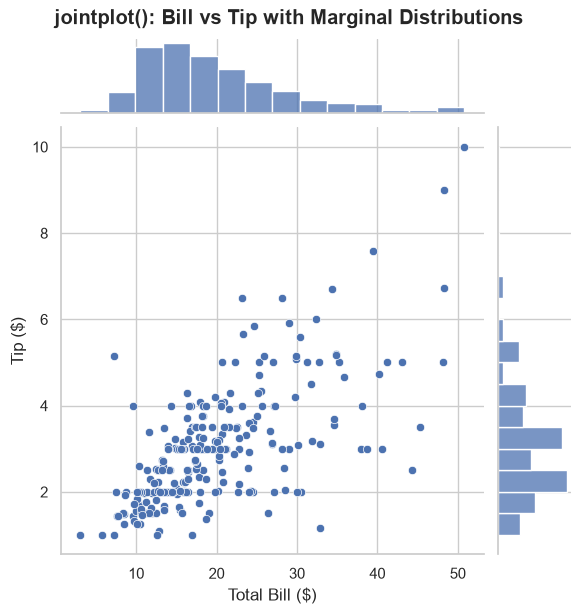

✅ jointplot with scatter: Shows correlation + individual distributions


In [6]:
# 📊 Basic jointplot with scatter and histograms
g = sns.jointplot(
    data=tips,
    x="total_bill",
    y="tip",
    kind="scatter",  # Can be: scatter, kde, hex, hist, reg, resid
    height=6,
    space=0.2
)
g.fig.suptitle("jointplot(): Bill vs Tip with Marginal Distributions", y=1.02, fontweight="bold")
g.set_axis_labels("Total Bill ($)", "Tip ($)")
save_fig("../exports/07_figure_level/jointplot_scatter.png")
plt.show()

print("✅ jointplot with scatter: Shows correlation + individual distributions")

✅ Plot saved to ../exports/07_figure_level/jointplot_kde.png


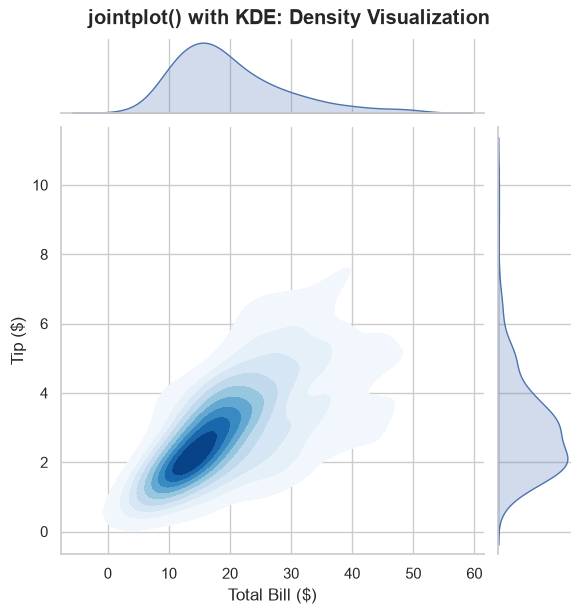

✅ jointplot with KDE: Better for dense data, shows density contours


In [7]:
# 📊 jointplot with KDE (Kernel Density Estimate)
g = sns.jointplot(
    data=tips,
    x="total_bill",
    y="tip",
    kind="kde",  # 👈 KDE shows density contours
    fill=True,
    height=6,
    space=0.2,
    cmap="Blues"
)
g.fig.suptitle("jointplot() with KDE: Density Visualization", y=1.02, fontweight="bold")
g.set_axis_labels("Total Bill ($)", "Tip ($)")
save_fig("../exports/07_figure_level/jointplot_kde.png")
plt.show()

print("✅ jointplot with KDE: Better for dense data, shows density contours")

✅ Plot saved to ../exports/07_figure_level/jointplot_reg.png


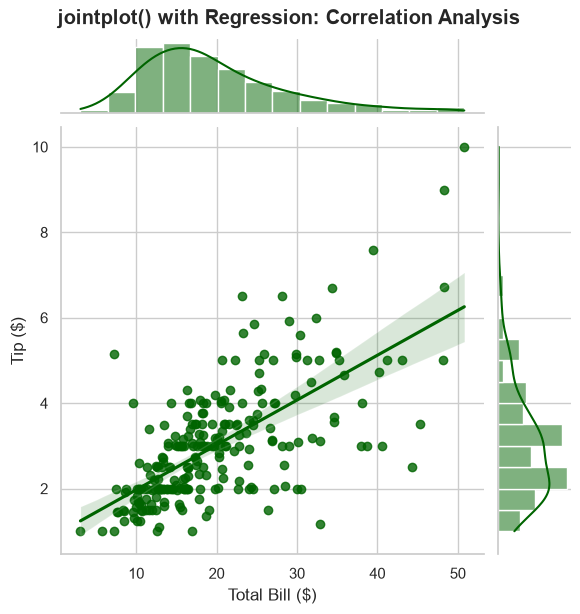

✅ jointplot with regression: Shows linear relationship + confidence interval


In [8]:
# 📊 jointplot with regression line
g = sns.jointplot(
    data=tips,
    x="total_bill",
    y="tip",
    kind="reg",  # 👈 Adds regression line with confidence interval
    height=6,
    space=0.2,
    color="darkgreen"
)
g.fig.suptitle("jointplot() with Regression: Correlation Analysis", y=1.02, fontweight="bold")
g.set_axis_labels("Total Bill ($)", "Tip ($)")
save_fig("../exports/07_figure_level/jointplot_reg.png")
plt.show()

print("✅ jointplot with regression: Shows linear relationship + confidence interval")

## 4️⃣ `lmplot()` - Figure-Level Regression Plots

**`lmplot()`** is the figure-level version of `regplot()` with built-in faceting.

**Key Features:**
- Regression analysis with confidence intervals
- Automatic faceting with `col`, `row`, `hue`
- Returns a `FacetGrid` object
- Can perform polynomial regression with `order` parameter
- Supports logistic regression with `logistic=True`

**Use Cases:**
- Comparing regressions across categories
- Multi-group regression analysis
- Testing relationship strength across subgroups

✅ Plot saved to ../exports/07_figure_level/lmplot_faceted.png


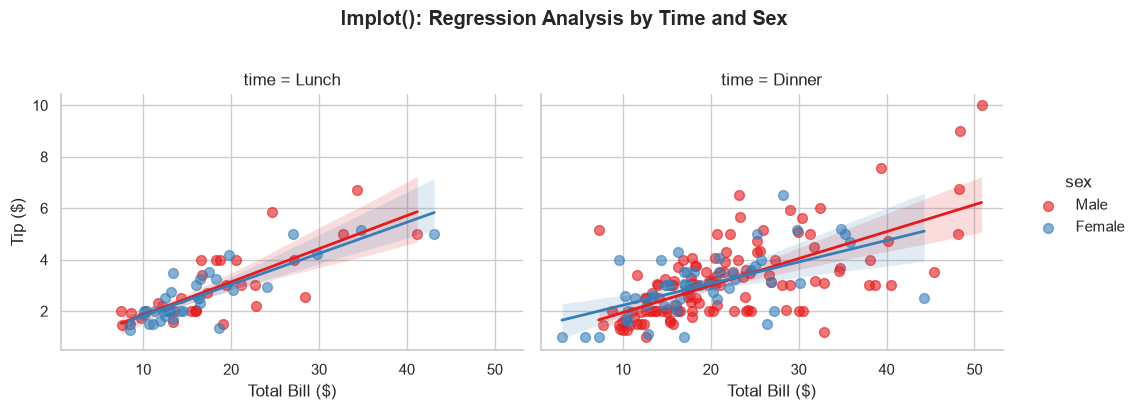

✅ lmplot with col and hue: Comparing regression lines across groups


In [9]:
# 📊 lmplot with faceting by columns
g = sns.lmplot(
    data=tips,
    x="total_bill",
    y="tip",
    col="time",  # 👈 Facet by time of day
    hue="sex",
    height=4,
    aspect=1.3,
    palette="Set1",
    scatter_kws={"alpha": 0.6, "s": 50},
    line_kws={"linewidth": 2}
)
g.set_axis_labels("Total Bill ($)", "Tip ($)")
g.fig.suptitle("lmplot(): Regression Analysis by Time and Sex", y=1.02, fontweight="bold")
g.tight_layout()
save_fig("../exports/07_figure_level/lmplot_faceted.png")
plt.show()

print("✅ lmplot with col and hue: Comparing regression lines across groups")

## 5️⃣ `displot()` - Figure-Level Distribution Plots

**`displot()`** is the figure-level equivalent of `histplot()`, `kdeplot()`, and `ecdfplot()`.

**Key Features:**
- Unified interface for distribution plots
- Built-in faceting with `col`, `row`, `hue`
- Multiple `kind` options: `hist`, `kde`, `ecdf`
- Returns a `FacetGrid` object
- Can show univariate or bivariate distributions

**Use Cases:**
- Comparing distributions across categories
- Multi-panel distribution analysis
- Quick exploratory distribution visualization

✅ Plot saved to ../exports/07_figure_level/displot_faceted.png


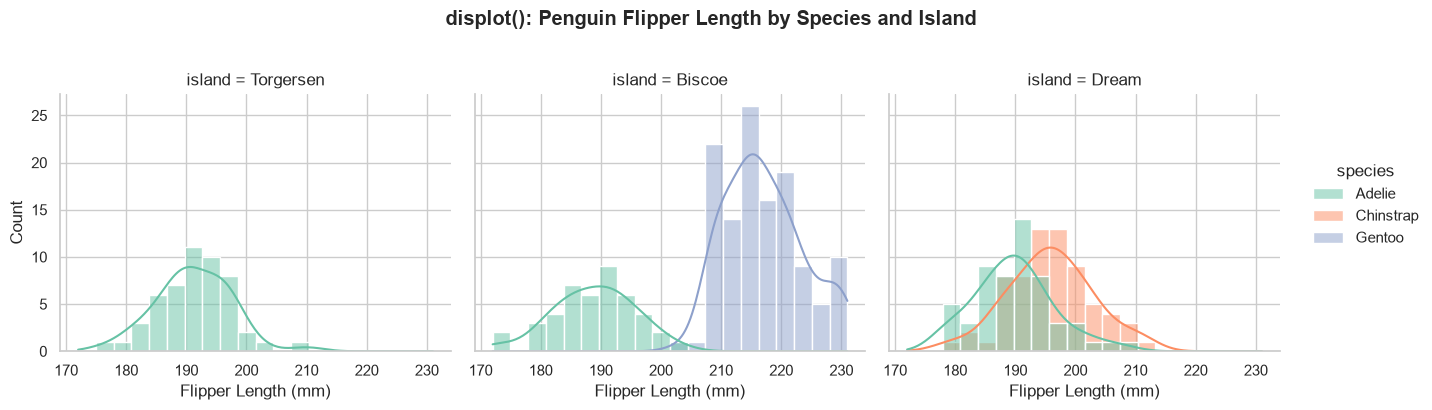

✅ displot with col faceting: Distribution comparison across islands


In [10]:
# 📊 displot with histogram and faceting
g = sns.displot(
    data=penguins,
    x="flipper_length_mm",
    hue="species",
    col="island",  # 👈 Creates separate plots by island
    kind="hist",  # Can be: hist, kde, ecdf
    kde=True,  # Add KDE curve on top
    height=4,
    aspect=1.1,
    bins=20,
    palette="Set2"
)
g.set_axis_labels("Flipper Length (mm)", "Count")
g.fig.suptitle("displot(): Penguin Flipper Length by Species and Island", y=1.02, fontweight="bold")
g.tight_layout()
save_fig("../exports/07_figure_level/displot_faceted.png")
plt.show()

print("✅ displot with col faceting: Distribution comparison across islands")

## 6️⃣ Comparison Table: Axes-Level vs Figure-Level

| Feature | Axes-Level | Figure-Level |
|---------|-----------|--------------|
| **Examples** | `scatterplot()`, `histplot()`, `boxplot()` | `relplot()`, `displot()`, `catplot()`, `lmplot()`, `jointplot()` |
| **Figure Creation** | Works with existing axes | Creates own figure |
| **Faceting** | Manual (requires loops) | Built-in (`col`, `row`, `hue`) |
| **Returns** | Axes object | FacetGrid or JointGrid object |
| **Integration** | Easy to combine multiple plot types | Difficult to combine with other plots |
| **Control** | Fine-grained matplotlib access | Higher-level abstraction |
| **Use When** | Custom layouts, complex figures | Quick faceting, consistent layouts |
| **Code Verbosity** | More code for faceting | Less code for multi-panel |
| **Flexibility** | Maximum flexibility | Optimized for faceting |

## 7️⃣ Decision Guide: When to Use Which?

### **Use Axes-Level Functions When:**
✅ You need to integrate Seaborn plots into custom matplotlib layouts  
✅ Combining multiple different plot types in one figure  
✅ You want fine-grained control over every aspect  
✅ Building complex dashboards with mixed visualization types  
✅ Working with existing figure/axes objects  

**Example Use Case:** Creating a 2x2 dashboard with scatter, box, violin, and heatmap

---

### **Use Figure-Level Functions When:**
✅ You want to quickly create faceted plots  
✅ Comparing the same plot type across categories  
✅ You need consistent, publication-ready layouts  
✅ Less code is preferred over maximum flexibility  
✅ Analyzing patterns across multiple dimensions (`col`, `row`, `hue`)  

**Example Use Case:** Comparing sales trends across regions, quarters, and product types

---

### **Quick Reference:**

| If you need... | Use... |
|----------------|--------|
| Scatterplot with faceting | `relplot(kind="scatter")` |
| Single scatterplot in custom layout | `scatterplot()` |
| Distribution across categories | `displot()` or `catplot()` |
| Single histogram | `histplot()` |
| Regression with facets | `lmplot()` |
| Single regression plot | `regplot()` |
| Bivariate with marginals | `jointplot()` |
| Categorical comparison across groups | `catplot()` |

## 🎯 Summary

You've now mastered the difference between axes-level and figure-level functions in Seaborn!

### **Key Takeaways:**

1. **Figure-Level Functions Create Their Own Figures:**
   - `relplot()`, `displot()`, `catplot()`, `lmplot()`, `jointplot()`
   - Built-in faceting with `col`, `row`, `hue`
   - Return `FacetGrid` or `JointGrid` objects

2. **Axes-Level Functions Work with Existing Axes:**
   - `scatterplot()`, `histplot()`, `boxplot()`, etc.
   - Maximum flexibility for custom layouts
   - Return `Axes` objects

3. **Choose Based on Your Needs:**
   - **Quick faceting** → Figure-level
   - **Custom layouts** → Axes-level
   - **Single plot** → Axes-level (less overhead)
   - **Multi-panel consistency** → Figure-level

4. **Special Functions:**
   - `jointplot()`: Bivariate analysis with marginal distributions
   - `lmplot()`: Regression with built-in faceting
   - `relplot()`: Unified scatter/line plots with faceting
   - `displot()`: Unified distribution plots with faceting

---

### **Next Steps:**
- Practice combining axes-level plots in custom layouts
- Experiment with `col_wrap` parameter for flexible faceting
- Explore `JointGrid` and `FacetGrid` customization methods
- Learn advanced categorical plots in Notebook 08